# Task success breakdown

This notebook visualizes per-task success columns (`task_i_success`) from `results/eval_results.csv`.

Use it to quickly inspect task-level strengths/weaknesses across runs.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "visualization" else Path.cwd().resolve()
CSV_PATH = REPO_ROOT / "results" / "eval_results.csv"

df = pd.read_csv(CSV_PATH)

task_cols = [c for c in df.columns if re.fullmatch(r"task_\d+_success", c)]
if not task_cols:
    raise ValueError("No task_*_success columns found")

print(f"Loaded {len(df)} rows")
print(f"Found {len(task_cols)} task success columns")

df[["experiment_name", "seed"] + task_cols].head(3)

Loaded 9 rows
Found 10 task success columns


,experiment_name,seed,task_0_success,task_1_success,task_2_success,task_3_success,task_4_success,task_5_success,task_6_success,task_7_success,task_8_success,task_9_success
0,eval_opd_task_4_seed186_spatial_step_50,186,0.012821,0.00641,0.025641,0.019231,0.025641,0.00641,0.019231,0.022436,0.016026,0.0
1,eval_opd_task_4_seed185_spatial_step_50,185,0.362500,0.00000,0.575000,0.387500,0.062500,0.00000,0.800000,0.025000,0.000000,0.0
2,eval_opd_task_1_seed185_spatial_step_50,185,0.575000,0.46250,0.700000,0.675000,0.087500,0.03750,0.450000,0.162500,0.000000,0.0


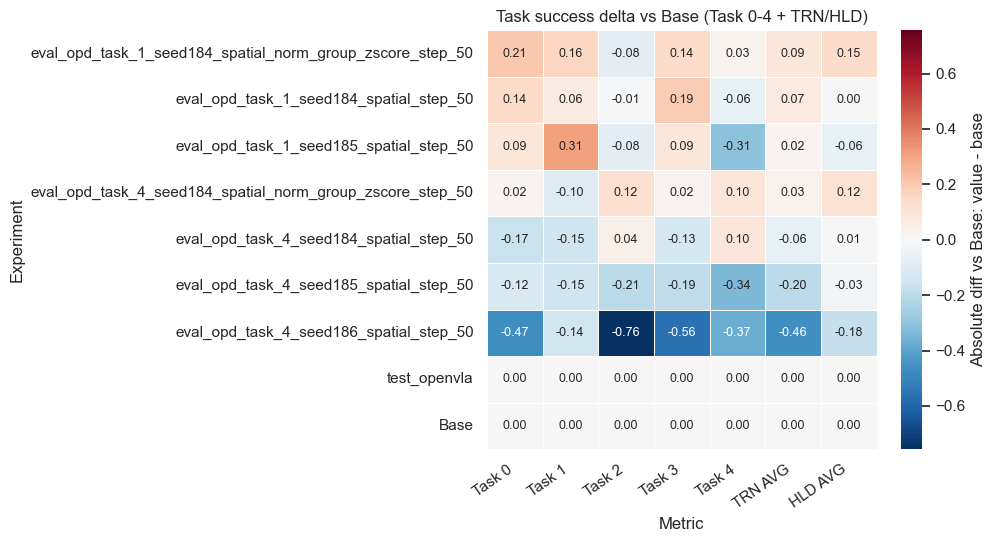

,Task 0,Task 1,Task 2,Task 3,Task 4,TRN AVG,HLD AVG
experiment_name,,,,,,,
eval_opd_task_1_seed184_spatial_norm_group_zscore_step_50,0.2063,0.1625,-0.0813,0.1437,0.0250,0.0912,0.1475
eval_opd_task_1_seed184_spatial_step_50,0.1438,0.0625,-0.0062,0.1937,-0.0625,0.0662,0.0000
eval_opd_task_1_seed185_spatial_step_50,0.0938,0.3125,-0.0813,0.0938,-0.3125,0.0212,-0.0625
eval_opd_task_4_seed184_spatial_norm_group_zscore_step_50,0.0188,-0.1000,0.1188,0.0187,0.1000,0.0312,0.1175
eval_opd_task_4_seed184_spatial_step_50,-0.1687,-0.1500,0.0437,-0.1313,0.1000,-0.0613,0.0050
eval_opd_task_4_seed185_spatial_step_50,-0.1187,-0.1500,-0.2063,-0.1938,-0.3375,-0.2013,-0.0275
eval_opd_task_4_seed186_spatial_step_50,-0.4684,-0.1436,-0.7556,-0.5620,-0.3744,-0.4608,-0.1797
test_openvla,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Base,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [2]:
# Heatmap: absolute difference vs Base (Task 0-4 + TRN/HLD)
if "experiment_name" not in df.columns:
    raise ValueError("experiment_name column missing")

task_cols_sorted = sorted(task_cols, key=lambda c: int(re.search(r"\d+", c).group()))
mean_by_exp_full = df.groupby("experiment_name")[task_cols_sorted].mean()

trn_cols = [f"task_{i}_success" for i in range(5) if f"task_{i}_success" in mean_by_exp_full.columns]
hld_cols = [f"task_{i}_success" for i in range(5, 10) if f"task_{i}_success" in mean_by_exp_full.columns]

plot_df = pd.DataFrame(index=mean_by_exp_full.index)
for i in range(5):
    src = f"task_{i}_success"
    plot_df[f"Task {i}"] = mean_by_exp_full[src] if src in mean_by_exp_full.columns else float("nan")

plot_df["TRN AVG"] = mean_by_exp_full[trn_cols].mean(axis=1) if trn_cols else float("nan")
plot_df["HLD AVG"] = mean_by_exp_full[hld_cols].mean(axis=1) if hld_cols else float("nan")

# Add explicit baseline row from test_openvla runs and convert all rows to absolute delta.
base_mask = df["experiment_name"].fillna("").str.fullmatch("test_openvla", case=False)
if not base_mask.any():
    raise ValueError("No base rows found (expected experiment_name == 'test_openvla')")

base_means = df.loc[base_mask, task_cols_sorted].mean()
base_row = {f"Task {i}": base_means.get(f"task_{i}_success", float("nan")) for i in range(5)}
base_row["TRN AVG"] = base_means[trn_cols].mean() if trn_cols else float("nan")
base_row["HLD AVG"] = base_means[hld_cols].mean() if hld_cols else float("nan")
plot_df.loc["Base"] = pd.Series(base_row)

base_series = plot_df.loc["Base"]
delta_df = plot_df.subtract(base_series, axis="columns")
delta_df.loc["Base"] = 0.0

max_abs = delta_df.abs().max().max()
max_abs = float(max_abs) if pd.notna(max_abs) and max_abs > 0 else 1.0

fig_w = max(10, 1.1 * len(delta_df.columns))
fig_h = max(5, 0.62 * len(delta_df))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(
    delta_df,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-max_abs,
    vmax=max_abs,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Absolute diff vs Base: value - base"},
    annot_kws={"size": 9},
    ax=ax,
)

ax.set_title("Task success delta vs Base (Task 0-4 + TRN/HLD)")
ax.set_xlabel("Metric")
ax.set_ylabel("Experiment")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

delta_df.round(4)

In [3]:
# Base model summary table (tasks 0-4 + TRN/HLD averages)
task_cols_sorted = sorted(task_cols, key=lambda c: int(re.search(r"\d+", c).group()))

# Use explicit baseline runs when present, otherwise fall back to all rows.
base_mask = df["experiment_name"].fillna("").str.fullmatch("test_openvla", case=False)
base_df = df.loc[base_mask] if base_mask.any() else df

base_means = base_df[task_cols_sorted].mean()

task_indices = [0, 1, 2, 3, 4]
trn_cols = [f"task_{i}_success" for i in range(5) if f"task_{i}_success" in base_means.index]
hld_cols = [f"task_{i}_success" for i in range(5, 10) if f"task_{i}_success" in base_means.index]

summary_row = {"Model": "Base"}
for i in task_indices:
    col = f"task_{i}_success"
    summary_row[f"Task {i}"] = base_means[col] if col in base_means.index else float("nan")

summary_row["TRN AVG"] = base_means[trn_cols].mean() if trn_cols else float("nan")
summary_row["HLD AVG"] = base_means[hld_cols].mean() if hld_cols else float("nan")

summary_df = pd.DataFrame([summary_row])
column_order = ["Model"] + [f"Task {i}" for i in task_indices] + ["TRN AVG", "HLD AVG"]
summary_df = summary_df[column_order].round(4)

summary_df

,Model,Task 0,Task 1,Task 2,Task 3,Task 4,TRN AVG,HLD AVG
0,Base,0.4812,0.15,0.7812,0.5812,0.4,0.4788,0.1925


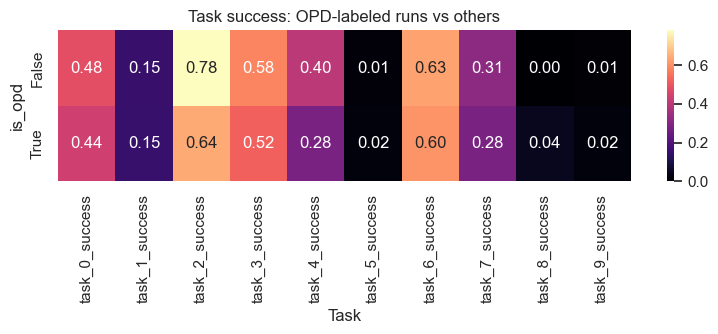

In [4]:
# Optional: compare only OPD-named runs vs all others (if names follow eval_opd_*)
if "experiment_name" in df.columns:
    tmp = df.copy()
    tmp["is_opd"] = tmp["experiment_name"].fillna("").str.contains("opd", case=False)
    opd_group = tmp.groupby("is_opd")[task_cols].mean()

    plt.figure(figsize=(max(8, 0.55 * len(task_cols)), 3.5))
    sns.heatmap(opd_group, annot=True, fmt=".2f", cmap="magma", cbar=True)
    plt.title("Task success: OPD-labeled runs vs others")
    plt.xlabel("Task")
    plt.ylabel("is_opd")
    plt.tight_layout()
    plt.show()

    opd_group